# The pre-registered fade on QueryDrivenBacktest — run + reconciliation

The STRG75 Q1 richness fade (thr 4bp, exit 25%, hold ≤ 15 sessions, fade
only, one open, lag-1 — parameters frozen in the 2026-08-04 findings)
executed through the production backtest engine: positions are
`STIRFutureOptionQuery` STRADDLE packages marked by the MDP's QL pricers,
entries/exits fire through Triggers, portfolio and realized PnL are the
engine's own bookkeeping.

Two deliverables: (1) the engine run over the full sample, with house
statistics; (2) trade-by-trade reconciliation against the research
replay (`famb_common.intra_quarter_backtest`) on the identical signal
panel — the port is only trustworthy if the two agree up to mark-source
and cost-timing differences.

In [1]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_fade_qdb import (PRE_REGISTERED, build_signal_panel,
                           closed_positions_frame, make_fade_backtest)
from famb_common import intra_quarter_backtest, n_contracts
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from RVUtils.SFRRVLab.stats import nw_tstat

print("pre-registered:", PRE_REGISTERED)
panel, holdings = build_signal_panel(return_holdings=True)
print(f"signal panel: {len(panel)} sessions, "
      f"{panel['as_of'].min().date()} -> {panel['as_of'].max().date()}, "
      f"{panel['symbol'].nunique()} holdings' symbols")

pre-registered: {'book': 'STRG75', 'rank': 1, 'thr_bp': 4.0, 'exit_frac': 0.25, 'max_hold': 15}


signal panel: 1052 sessions, 2022-03-08 -> 2026-07-28, 18 holdings' symbols


## The engine run

In [2]:
mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
bt = make_fade_backtest(panel, mdp, contracts=1.0, show_progress=True)
bt.run()
cl = closed_positions_frame(bt)
print(f"\nclosed positions: {len(cl)}")
if len(cl):
    show = [c for c in ("opened_at", "closed_at", "realized_pnl") if
            c in cl.columns]
    print(cl[show].round(2).to_string(index=False))
    total = cl["realized_pnl"].sum()
    hit = (cl["realized_pnl"] > 0).mean()
    print(f"\nQDB: {len(cl)} trades  hit {hit:.0%}  "
          f"total ${total:+,.0f} per 1-lot "
          f"({total / 25.0:+.1f}bp premium equivalent)")

STRG75 fade (QDB):   0%|          | 0/1052 [00:00<?, ?step/s]

STRG75 fade (QDB):   0%|          | 2/1052 [00:00<02:14,  7.80step/s]

STRG75 fade (QDB):  18%|█▊        | 192/1052 [00:00<00:01, 684.77step/s]

STRG75 fade (QDB):  41%|████      | 431/1052 [00:00<00:00, 1261.23step/s]

STRG75 fade (QDB):  74%|███████▎  | 774/1052 [00:00<00:00, 1962.07step/s]

STRG75 fade (QDB): 100%|██████████| 1052/1052 [00:00<00:00, 1706.81step/s]


closed positions: 16
                opened_at                 closed_at  realized_pnl
2022-03-09 17:00:00-05:00 2022-03-30 17:00:00-04:00         43.75
2022-04-22 17:00:00-04:00 2022-05-05 17:00:00-04:00        193.75
2022-06-13 17:00:00-04:00 2022-08-29 17:00:00-04:00       -193.75
2022-09-14 17:00:00-04:00 2022-10-05 17:00:00-04:00         -6.25
2022-10-06 17:00:00-04:00 2022-10-27 17:00:00-04:00         68.75
2023-03-20 17:00:00-04:00 2023-04-13 17:00:00-04:00       1087.50
2023-04-14 17:00:00-04:00 2023-05-05 17:00:00-04:00         37.50
2023-05-08 17:00:00-04:00 2023-05-24 17:00:00-04:00        125.00
2023-06-14 17:00:00-04:00 2023-07-07 17:00:00-04:00         43.75
2023-12-14 17:00:00-05:00 2024-01-08 17:00:00-05:00         43.75
2024-08-05 17:00:00-04:00 2024-08-14 17:00:00-04:00        168.75
2024-09-11 17:00:00-04:00 2024-10-02 17:00:00-04:00         25.00
2025-03-12 17:00:00-04:00 2025-04-02 17:00:00-04:00          6.25
2025-04-07 17:00:00-04:00 2025-04-29 17:00:00-04:00   

engine equity: +1,944 USD end, 1051 marked days, Sharpe +0.79, NW t +2.03, maxDD -506 USD


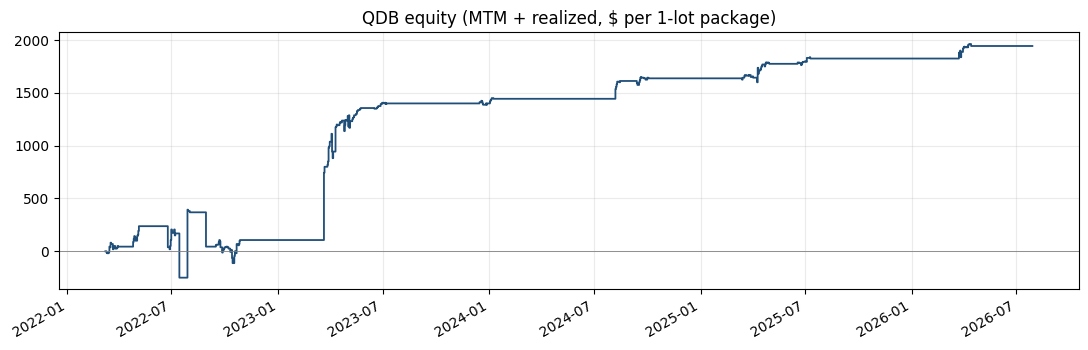

In [3]:
# mtm_history is the TOTAL account value (open MTM + cumulative realized) —
# verified: it ends at the sum of realized PnL with no open positions
equity = pd.Series(bt.mtm_history).sort_index()
daily = equity.diff().dropna()
sd = daily.std(ddof=1)
if len(daily) > 5 and sd > 0:
    print(f"engine equity: {equity.iloc[-1]:+,.0f} USD end, "
          f"{len(daily)} marked days, "
          f"Sharpe {daily.mean() / sd * np.sqrt(252):+.2f}, "
          f"NW t {nw_tstat(daily.to_numpy()):+.2f}, "
          f"maxDD {(equity - equity.cummax()).min():,.0f} USD")
else:
    print("equity series too short/flat to annualize")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.step(equity.index, equity.values, where="post", color="#1f4e79", lw=1.3)
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("QDB equity (MTM + realized, $ per 1-lot package)")
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Reconciliation vs the research replay

Same panel, same parameters, two engines. Replay marks = panel settle
premiums; engine marks = MDP QL pricers at the NY close (same barchart
EOD settles underneath). Costs: replay books a round trip per trade;
the engine books both sides as the unwind fee. Agreement is expected to
a few $ per trade; systematic gaps mean a port bug.

In [4]:
replay = intra_quarter_backtest(
    holdings, thr_bp=PRE_REGISTERED["thr_bp"],
    exit_frac=PRE_REGISTERED["exit_frac"],
    max_hold=PRE_REGISTERED["max_hold"], direction="fade",
    cost_mult=1.0, n_legs=n_contracts(PRE_REGISTERED["book"]))
rp = pd.DataFrame(replay)
rp["net_usd"] = rp["net_bp"] * 25.0
print(f"replay: {len(rp)} trades  total ${rp['net_usd'].sum():+,.0f}")

if len(cl) and len(rp):
    q = cl.copy()
    q["entry_d"] = (pd.to_datetime(q["opened_at"])
                    .dt.tz_localize(None).dt.normalize())
    rp["entry_d"] = pd.to_datetime(rp["entry"]).dt.normalize()
    m = rp.merge(q, on="entry_d", how="outer", suffixes=("_replay", "_qdb"),
                 indicator=True)
    matched = m[m["_merge"] == "both"]
    print(f"\nmatched on entry date: {len(matched)}/{max(len(rp), len(cl))}")
    if len(matched):
        comp = pd.DataFrame({
            "entry": matched["entry_d"].dt.date,
            "exit_replay": pd.to_datetime(matched["exit"]).dt.date,
            "exit_qdb": pd.to_datetime(matched["closed_at"]).dt.date,
            "replay_usd": matched["net_usd"].round(1),
            "qdb_usd": matched["realized_pnl"].round(1),
            "diff_usd": (matched["realized_pnl"]
                         - matched["net_usd"]).round(1),
        })
        print(comp.to_string(index=False))
        print(f"\nmean |diff| ${comp['diff_usd'].abs().mean():.1f}  "
              f"max |diff| ${comp['diff_usd'].abs().max():.1f}  "
              f"corr {np.corrcoef(comp['replay_usd'], comp['qdb_usd'])[0, 1]:.3f}")
    unmatched = m[m["_merge"] != "both"]
    if len(unmatched):
        print(f"\nunmatched entries ({len(unmatched)}):")
        print(unmatched[["entry_d", "_merge"]].to_string(index=False))

replay: 16 trades  total $+1,881

matched on entry date: 13/16
     entry exit_replay   exit_qdb  replay_usd  qdb_usd  diff_usd
2022-03-09  2022-03-30 2022-03-30        43.8     43.7      -0.0
2022-04-22  2022-05-05 2022-05-05       193.8    193.8       0.0
2022-06-13  2022-08-29 2022-08-29      -192.8   -193.8      -0.9
2022-09-14  2022-10-05 2022-10-05        -6.2     -6.3      -0.0
2023-03-20  2023-04-13 2023-04-13      1086.7   1087.5       0.8
2023-06-14  2023-07-07 2023-07-07        43.8     43.8       0.0
2023-12-14  2024-01-08 2024-01-08        43.8     43.8       0.0
2024-08-05  2024-08-14 2024-08-14       168.8    168.8       0.0
2024-09-11  2024-10-02 2024-10-02        25.0     25.0       0.0
2025-03-12  2025-04-02 2025-04-02         6.2      6.2       0.0
2025-04-07  2025-04-29 2025-04-29       131.2    131.2       0.0
2025-06-16  2025-07-09 2025-07-09        50.0     50.0      -0.0
2026-03-20  2026-04-13 2026-04-13       118.8    118.8       0.0

mean |diff| $0.1  max |dif

## What the port is for

The research replay stays the historical evidence; this engine is the
forward instrument. Extending the TimeGrid forward day by day turns it
into the pre-registered one-trial test: signals from the same lattice
machinery, marks from the production pricers, no parameter left free.